In [2]:
import sys
!{sys.executable} -m pip install prophet lightgbm

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\dell\Desktop\New folder
['.ipynb_checkpoints', '.virtual_documents', 'ai_autofix_extension', 'archive.zip', 'Assinment No.1.ipynb', 'attrition_model.pkl', 'attrition_pipeline.ipynb', 'bank.py', 'Code Anayalizer.ipynb', 'Error Solver 3.0.ipynb', 'Error solver.ipynb', 'legacy.py', 'Practice (7-may).ipynb', 'README.md', 'requirements.txt', 'rossmann-store-sales.zip', 'sales_forecasting .ipynb', 'test.py', 'Untitled.ipynb', 'WA_Fn-UseC_-HR-Employee-Attrition.csv', 'Youtube class 10.ipynb', 'Youtube Class 11.ipynb', 'Youtube Class 12.ipynb', 'Youtube Class 2 Lecture-Copy1.ipynb', 'Youtube Class 8.ipynb', 'Youtube Class3.ipynb', 'Youtube Class4.ipynb', 'Youtube Class5.ipynb', 'Youtube Class6 & Class7.ipynb', 'Youtube Class7.ipynb', 'Youtube Class9.ipynb']


In [5]:
import zipfile
with zipfile.ZipFile('rossmann-store-sales.zip', 'r') as z:
    z.extractall('.')
print("Extracted!")
print(os.listdir())

Extracted!
['.ipynb_checkpoints', '.virtual_documents', 'ai_autofix_extension', 'archive.zip', 'Assinment No.1.ipynb', 'attrition_model.pkl', 'attrition_pipeline.ipynb', 'bank.py', 'Code Anayalizer.ipynb', 'Error Solver 3.0.ipynb', 'Error solver.ipynb', 'legacy.py', 'Practice (7-may).ipynb', 'README.md', 'requirements.txt', 'rossmann-store-sales.zip', 'sales_forecasting .ipynb', 'sample_submission.csv', 'store.csv', 'test.csv', 'test.py', 'train.csv', 'Untitled.ipynb', 'WA_Fn-UseC_-HR-Employee-Attrition.csv', 'Youtube class 10.ipynb', 'Youtube Class 11.ipynb', 'Youtube Class 12.ipynb', 'Youtube Class 2 Lecture-Copy1.ipynb', 'Youtube Class 8.ipynb', 'Youtube Class3.ipynb', 'Youtube Class4.ipynb', 'Youtube Class5.ipynb', 'Youtube Class6 & Class7.ipynb', 'Youtube Class7.ipynb', 'Youtube Class9.ipynb']


In [6]:
train = pd.read_csv('train.csv', low_memory=False)
store = pd.read_csv('store.csv')

print("Train shape:", train.shape)
print("Store shape:", store.shape)
print("\nTrain columns:", train.columns.tolist())

Train shape: (1017209, 9)
Store shape: (1115, 10)

Train columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']


In [7]:
df = pd.merge(train, store, on='Store', how='left')

df['Date'] = pd.to_datetime(df['Date'])

df = df[(df['Open'] == 1) & (df['Sales'] > 0)]

selected_stores = [1, 2, 3, 4, 5]
df = df[df['Store'].isin(selected_stores)]

print("Shape after filtering:", df.shape)
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Stores:", df['Store'].unique())

Shape after filtering: (3907, 18)
Date range: 2013-01-02 00:00:00 to 2015-07-31 00:00:00
Stores: [1 2 3 4 5]


In [8]:
df = df.sort_values(['Store', 'Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend'] = df['DayOfWeek'].isin([6, 7]).astype(int)

df['Lag_7'] = df.groupby('Store')['Sales'].shift(7)
df['Lag_14'] = df.groupby('Store')['Sales'].shift(14)
df['Rolling_Mean_7'] = df.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(7).mean())
df['Rolling_Mean_14'] = df.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(14).mean())

df = df.dropna()

print("Shape after feature engineering:", df.shape)
print("New features:", ['Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'Lag_7', 'Lag_14', 'Rolling_Mean_7', 'Rolling_Mean_14'])

Shape after feature engineering: (1535, 27)
New features: ['Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'Lag_7', 'Lag_14', 'Rolling_Mean_7', 'Rolling_Mean_14']


In [14]:
df = pd.merge(train, store, on='Store', how='left')
df['Date'] = pd.to_datetime(df['Date'])
df = df[(df['Open'] == 1) & (df['Sales'] > 0)]
selected_stores = [2, 3, 10, 20, 30]
df = df[df['Store'].isin(selected_stores)]
df = df.sort_values(['Store', 'Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend'] = df['DayOfWeek'].isin([6, 7]).astype(int)
df['Lag_7'] = df.groupby('Store')['Sales'].shift(7)
df['Lag_14'] = df.groupby('Store')['Sales'].shift(14)
df['Rolling_Mean_7'] = df.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(7).mean())
df['Rolling_Mean_14'] = df.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(14).mean())
df = df.dropna()
print("Shape:", df.shape)
print("Stores:", df['Store'].unique())

Shape: (2903, 27)
Stores: [ 2  3 20 30]


In [15]:
store2 = df[df['Store'] == 2].set_index('Date')['Sales']

result = adfuller(store2)
print("ADF Statistic:", round(result[0], 4))
print("p-value:", round(result[1], 4))

if result[1] < 0.05:
    print("Result: Stationary - no differencing needed")
else:
    print("Result: Non-stationary - differencing needed")

ADF Statistic: -5.3717
p-value: 0.0
Result: Stationary - no differencing needed


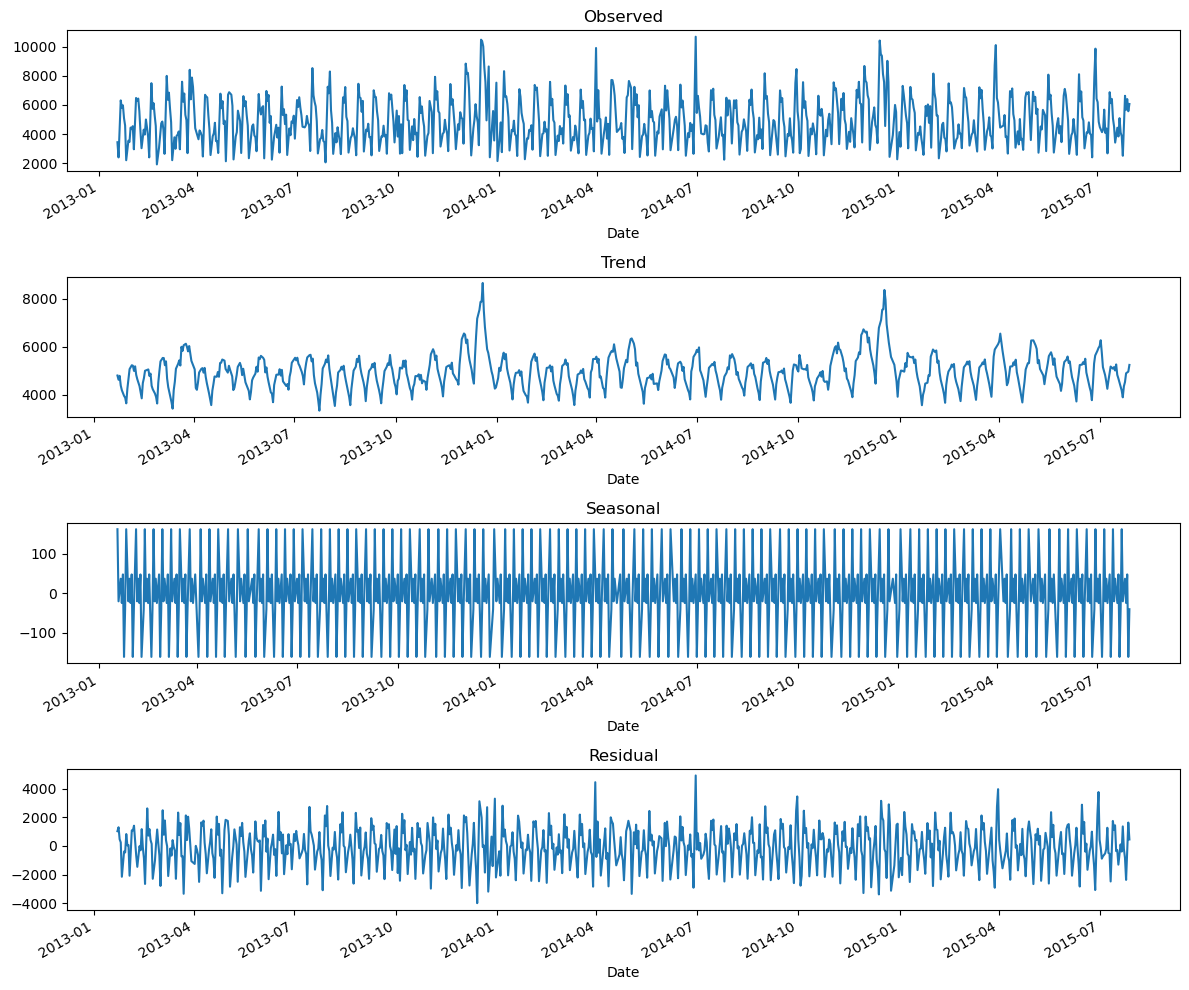

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

store2_series = df[df['Store'] == 2].set_index('Date')['Sales'].sort_index()

decomposition = seasonal_decompose(store2_series, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.savefig('seasonal_decomposition.png')
plt.show()

In [17]:
cutoff_date = '2015-06-01'

train_df = df[df['Date'] < cutoff_date]
test_df = df[df['Date'] >= cutoff_date]

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)
print("Train date range:", train_df['Date'].min(), "to", train_df['Date'].max())
print("Test date range:", test_df['Date'].min(), "to", test_df['Date'].max())

Train size: (2694, 27)
Test size: (209, 27)
Train date range: 2013-01-18 00:00:00 to 2015-05-30 00:00:00
Test date range: 2015-06-01 00:00:00 to 2015-07-31 00:00:00


In [18]:
store2_train = train_df[train_df['Store'] == 2][['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
store2_test = test_df[test_df['Store'] == 2][['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
prophet_model.fit(store2_train)

future = prophet_model.make_future_dataframe(periods=len(store2_test))
forecast = prophet_model.predict(future)

prophet_pred = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(len(store2_test))

mae = mean_absolute_error(store2_test['y'].values, prophet_pred['yhat'].values)
rmse = np.sqrt(mean_squared_error(store2_test['y'].values, prophet_pred['yhat'].values))
mape = np.mean(np.abs((store2_test['y'].values - prophet_pred['yhat'].values) / store2_test['y'].values)) * 100

print("Prophet Results - Store 2:")
print(f"MAE:  {round(mae, 2)}")
print(f"RMSE: {round(rmse, 2)}")
print(f"MAPE: {round(mape, 2)}%")

22:15:33 - cmdstanpy - INFO - Chain [1] start processing
22:15:34 - cmdstanpy - INFO - Chain [1] done processing


Prophet Results - Store 2:
MAE:  1438.71
RMSE: 1814.58
MAPE: 32.26%


In [19]:
features = ['Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 
            'DayOfWeek', 'Promo', 'SchoolHoliday',
            'Lag_7', 'Lag_14', 'Rolling_Mean_7', 'Rolling_Mean_14']

store2_train_lgb = train_df[train_df['Store'] == 2]
store2_test_lgb = test_df[test_df['Store'] == 2]

X_train = store2_train_lgb[features]
y_train = store2_train_lgb['Sales']
X_test = store2_test_lgb[features]
y_test = store2_test_lgb['Sales']

lgb_model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)

mae = mean_absolute_error(y_test, lgb_pred)
rmse = np.sqrt(mean_squared_error(y_test, lgb_pred))
mape = np.mean(np.abs((y_test.values - lgb_pred) / y_test.values)) * 100

print("LightGBM Results - Store 2:")
print(f"MAE:  {round(mae, 2)}")
print(f"RMSE: {round(rmse, 2)}")
print(f"MAPE: {round(mape, 2)}%")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000694 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1075
[LightGBM] [Info] Number of data points in the train set: 717, number of used features: 12
[LightGBM] [Info] Start training from score 4956.389121
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f